In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import cv2
import zipfile
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [3]:
img_zip_filepath='/Users/greysonnewton/Library/CloudStorage/OneDrive-UniversityOfHouston/FALL_2025/BigDataAnalytics(PETR)/big-data-analytics/big-data-analytics/midterms/final/700images.zip'
img_raw_dir ='/Users/greysonnewton/Library/CloudStorage/OneDrive-UniversityOfHouston/FALL_2025/BigDataAnalytics(PETR)/big-data-analytics/big-data-analytics/midterms/final/images/raw'
img_aug_dir='/Users/greysonnewton/Library/CloudStorage/OneDrive-UniversityOfHouston/FALL_2025/BigDataAnalytics(PETR)/big-data-analytics/big-data-analytics/midterms/final/images/aug'

In [20]:
import os

unzip_raw = False

# Unzip all images
def unzip(zip_file, destination):
    with zipfile.ZipFile(zip_file, 'r') as zf:
        zf.extractall(destination)

if unzip_raw:
  os.makedirs(img_raw_dir,exist_ok=True)
  unzip(zip_file=img_zip_filepath, destination=img_raw_dir)

import shutil
for f in os.listdir(os.path.join(img_raw_dir, '700images')):
  shutil.move(
      os.path.join(img_raw_dir, '700images', f),
      os.path.join(img_raw_dir, f),
      )

In [5]:
import pandas as pd
# Load the CSV data

data = pd.read_csv('final_code_data.csv')
print(data.head())
print(f"Total number of samples: {len(data)}")

   image_number  Penetration_depth (nm)  Load (mN)  H (GPa)
0             1                    1760     99.913     2.07
1             2                    1954    149.694     2.12
2             3                    1968    149.817     2.81
3             4                    2228    149.910     1.93
4             5                    2035    149.953     2.40
Total number of samples: 700


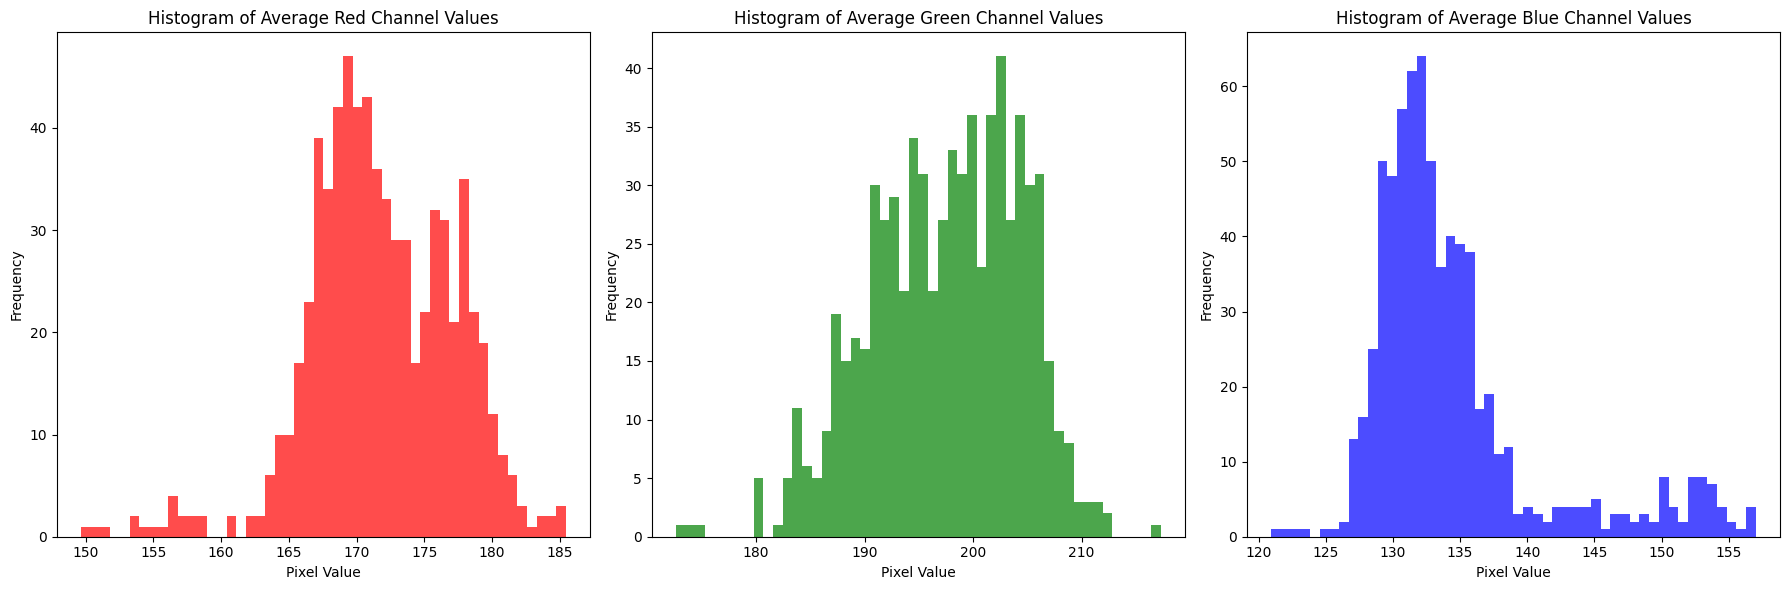

In [21]:
import numpy as np

def calculate_avg_rgb(image_dir, image_numbers, image_type='JPG'):
    """Calculate average RGB values for each image"""
    avg_r = []
    avg_g = []
    avg_b = []
    valid_images = []

    for img_num in image_numbers:
        img_path = os.path.join(image_dir, f"{img_num}.{image_type}")  # Adjust file extension if needed
        if os.path.exists(img_path):
            try:
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                avg_r.append(np.mean(img[:,:,0]))
                avg_g.append(np.mean(img[:,:,1]))
                avg_b.append(np.mean(img[:,:,2]))
                valid_images.append(img_num)
            except Exception as e:
                print(f"Error processing image {img_num}: {e}")
        else:
            print(f"File {img_path} does not exist")
    return valid_images, avg_r, avg_g, avg_b

# Calculate average RGB
valid_images, avg_r, avg_g, avg_b = calculate_avg_rgb(img_raw_dir, data['image_number'])

# Create a DataFrame with the RGB values
rgb_df = pd.DataFrame({
    'image_number': valid_images,
    'avg_r': avg_r,
    'avg_g': avg_g,
    'avg_b': avg_b
})

# Plot histograms
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(avg_r, bins=50, color='red', alpha=0.7)
plt.title('Histogram of Average Red Channel Values')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(avg_g, bins=50, color='green', alpha=0.7)
plt.title('Histogram of Average Green Channel Values')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(avg_b, bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Average Blue Channel Values')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('rgb_histograms.png')
plt.show()

# 2. Remove Outliers

Number of outliers detected: 21
Number of samples after outlier removal: 679


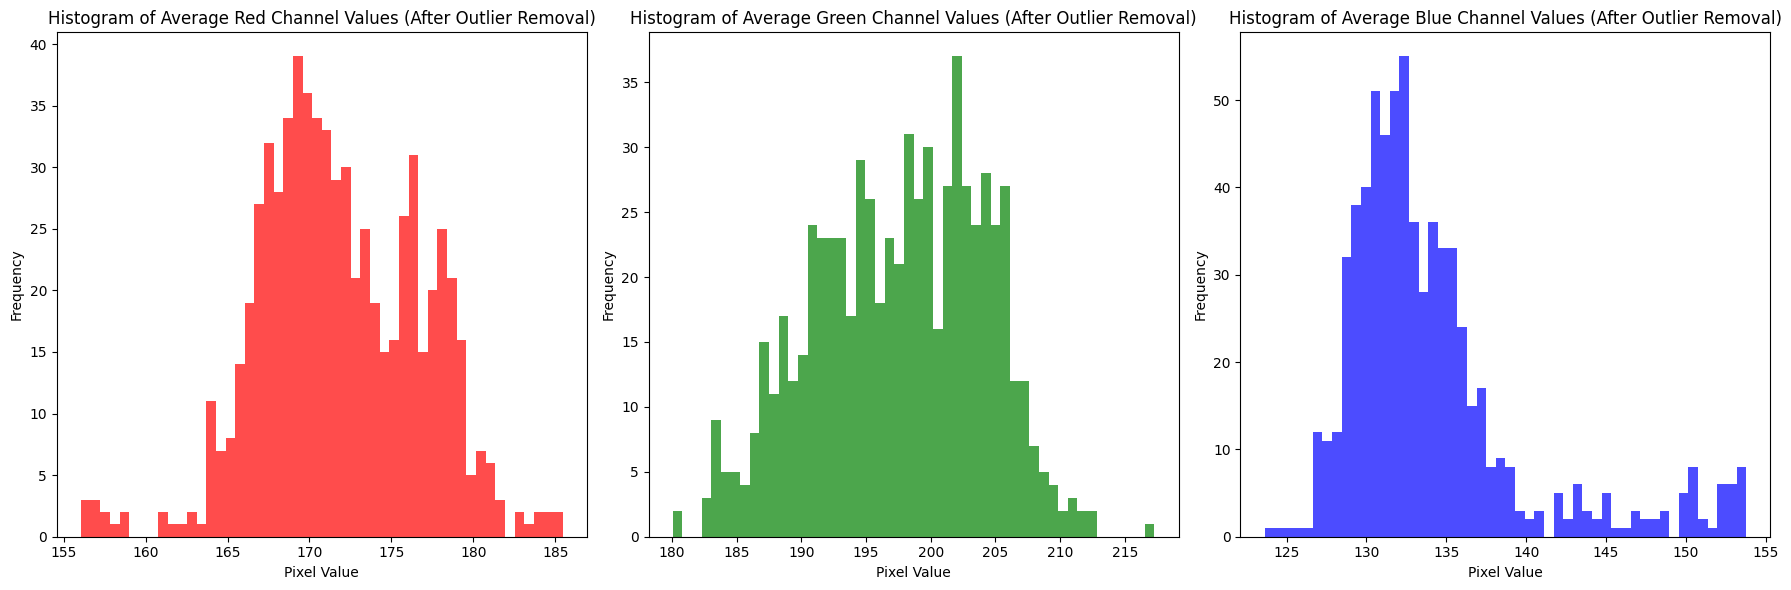

<Figure size 1200x800 with 0 Axes>

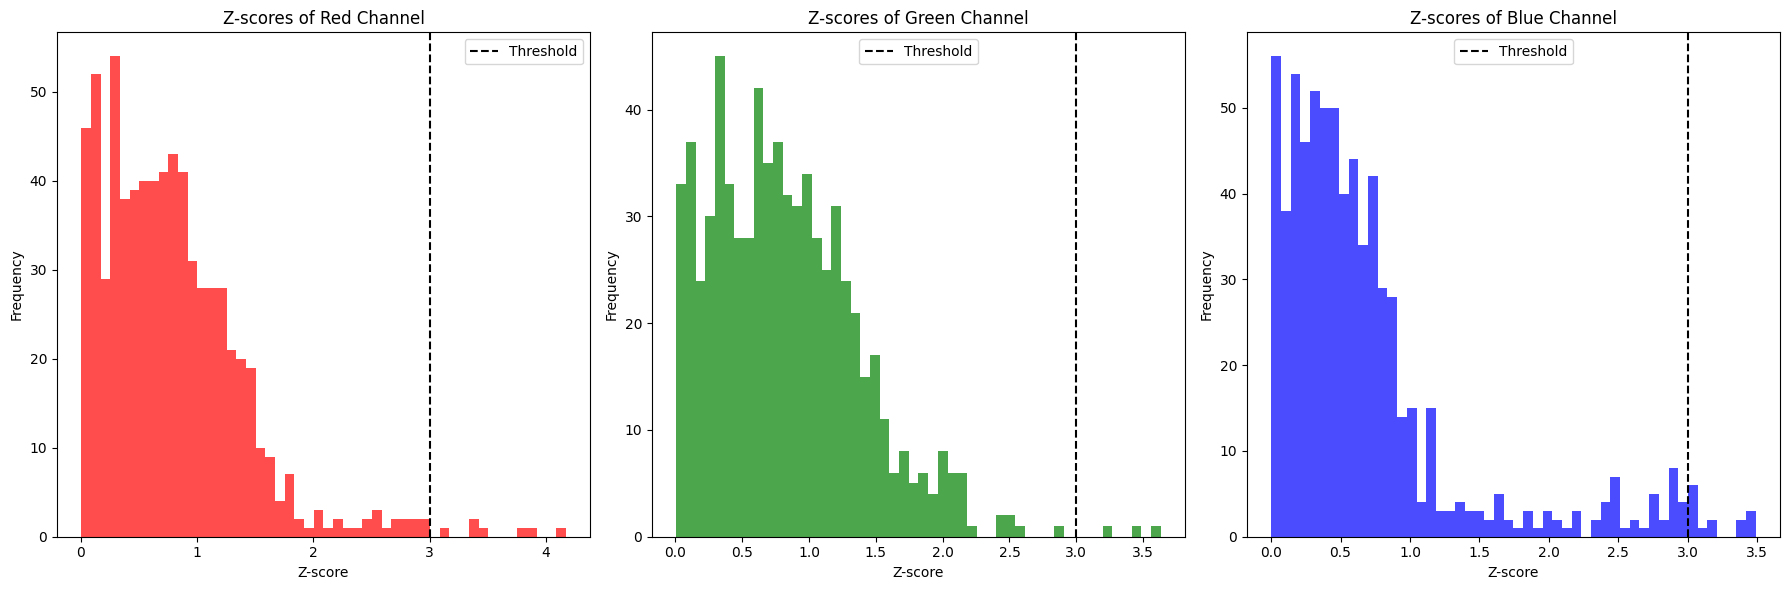

In [23]:
# STEP 2: Analyze pixel values and eliminate outliers

# First, let's define a function to detect outliers using z-score
def detect_outliers(rgb_df, z_threshold=3.0):
    """
    Detect outliers in RGB values using z-score method
    Returns a boolean mask where True indicates an outlier
    """
    z_scores = {}
    outliers = {}

    for channel in ['avg_r', 'avg_g', 'avg_b']:
        mean = np.mean(rgb_df[channel])
        std = np.std(rgb_df[channel])
        z_scores[channel] = np.abs((rgb_df[channel] - mean) / std)
        outliers[channel] = z_scores[channel] > z_threshold

    # Combined outlier detection (image is outlier if any channel is outlier)
    combined_outliers = outliers['avg_r'] | outliers['avg_g'] | outliers['avg_b']

    return combined_outliers, z_scores

# Detect outliers
outliers, z_scores = detect_outliers(rgb_df)
print(f"Number of outliers detected: {sum(outliers)}")

# Create a clean dataset without outliers
clean_rgb_df = rgb_df[~outliers]
clean_image_numbers = clean_rgb_df['image_number'].tolist()

# Merge with original data to get a clean dataset
clean_data = data[data['image_number'].isin(clean_image_numbers)]
print(f"Number of samples after outlier removal: {len(clean_data)}")

# Plot histograms after outlier removal to see the difference
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(clean_rgb_df['avg_r'], bins=50, color='red', alpha=0.7)
plt.title('Histogram of Average Red Channel Values (After Outlier Removal)')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(clean_rgb_df['avg_g'], bins=50, color='green', alpha=0.7)
plt.title('Histogram of Average Green Channel Values (After Outlier Removal)')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(clean_rgb_df['avg_b'], bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Average Blue Channel Values (After Outlier Removal)')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('rgb_histograms_clean.png')
plt.show()

# Let's visualize some of the outliers to understand what makes them outliers
def display_sample_images(rgb_df, outliers, img_raw_dir, num_samples=3, image_type='JPG'):
    """Display sample images of outliers and non-outliers"""
    outlier_indices = np.where(outliers)[0][:num_samples]
    non_outlier_indices = np.where(~outliers)[0][:num_samples]

    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(outlier_indices):
        img_num = rgb_df.iloc[idx]['image_number']
        img_path = os.path.join(img_raw_dir, f"{img_num}.{image_type}")
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(2, num_samples, i+1)
            plt.imshow(img)
            plt.title(f"Outlier {img_num}\nR:{rgb_df.iloc[idx]['avg_r']:.1f}, G:{rgb_df.iloc[idx]['avg_g']:.1f}, B:{rgb_df.iloc[idx]['avg_b']:.1f}")
            plt.axis('off')

    for i, idx in enumerate(non_outlier_indices):
        img_num = rgb_df.iloc[idx]['image_number']
        img_path = os.path.join(img_raw_dir, f"{img_num}.{image_type}")
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(2, num_samples, num_samples+i+1)
            plt.imshow(img)
            plt.title(f"Non-Outlier {img_num}\nR:{rgb_df.iloc[idx]['avg_r']:.1f}, G:{rgb_df.iloc[idx]['avg_g']:.1f}, B:{rgb_df.iloc[idx]['avg_b']:.1f}")
            plt.axis('off')

    plt.tight_layout()
    plt.savefig('outlier_comparison.png')
    plt.show()

# Display sample outlier vs non-outlier images
display_sample_images(rgb_df, outliers, img_raw_dir, image_type='JPG')

# Let's also analyze the distribution of z-scores to understand the threshold better
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(z_scores['avg_r'], bins=50, color='red', alpha=0.7)
plt.axvline(x=3.0, color='black', linestyle='--', label='Threshold')
plt.title('Z-scores of Red Channel')
plt.xlabel('Z-score')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(z_scores['avg_g'], bins=50, color='green', alpha=0.7)
plt.axvline(x=3.0, color='black', linestyle='--', label='Threshold')
plt.title('Z-scores of Green Channel')
plt.xlabel('Z-score')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(z_scores['avg_b'], bins=50, color='blue', alpha=0.7)
plt.axvline(x=3.0, color='black', linestyle='--', label='Threshold')
plt.title('Z-scores of Blue Channel')
plt.xlabel('Z-score')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.savefig('z_score_histograms.png')
plt.show()

# Create a discussion about the outlier detection solution
# print("""
# Outlier Detection Analysis:
#
# Method: Z-score thresholding with a threshold of 3.0 standard deviations
# - This method identifies values that are more than 3 standard deviations from the mean
# - An image is considered an outlier if any of its RGB channels exceed the threshold
# - This approach assumes a normal distribution of pixel values
#
# Observations:
# - The histograms show the distribution of RGB values before and after outlier removal
# - The z-score histograms help visualize the distribution of deviations
# - Visual inspection of outlier images reveals they are significantly different from the majority
#
# Justification:
# - Z-score method is effective for this task because it's channel-specific
# - The threshold of 3.0 is a common statistical choice representing ~99.7% confidence
# - Outlier removal ensures the model training will not be biased by anomalous images
# - The cleaned dataset is more representative of the typical hardness test image
#
# Impact on dataset:
# - Original dataset size: {len(rgb_df)} images
# - After outlier removal: {len(clean_rgb_df)} images
# - Removed: {len(rgb_df) - len(clean_rgb_df)} images ({100 * (len(rgb_df) - len(clean_rgb_df))/len(rgb_df):.2f}%)
# """.format(len(rgb_df), len(clean_rgb_df), len(rgb_df) - len(clean_rgb_df), 100 * (len(rgb_df) - len(clean_rgb_df))/len(rgb_df)))

# 3. Augment


Demonstrating augmentation with image number: 676


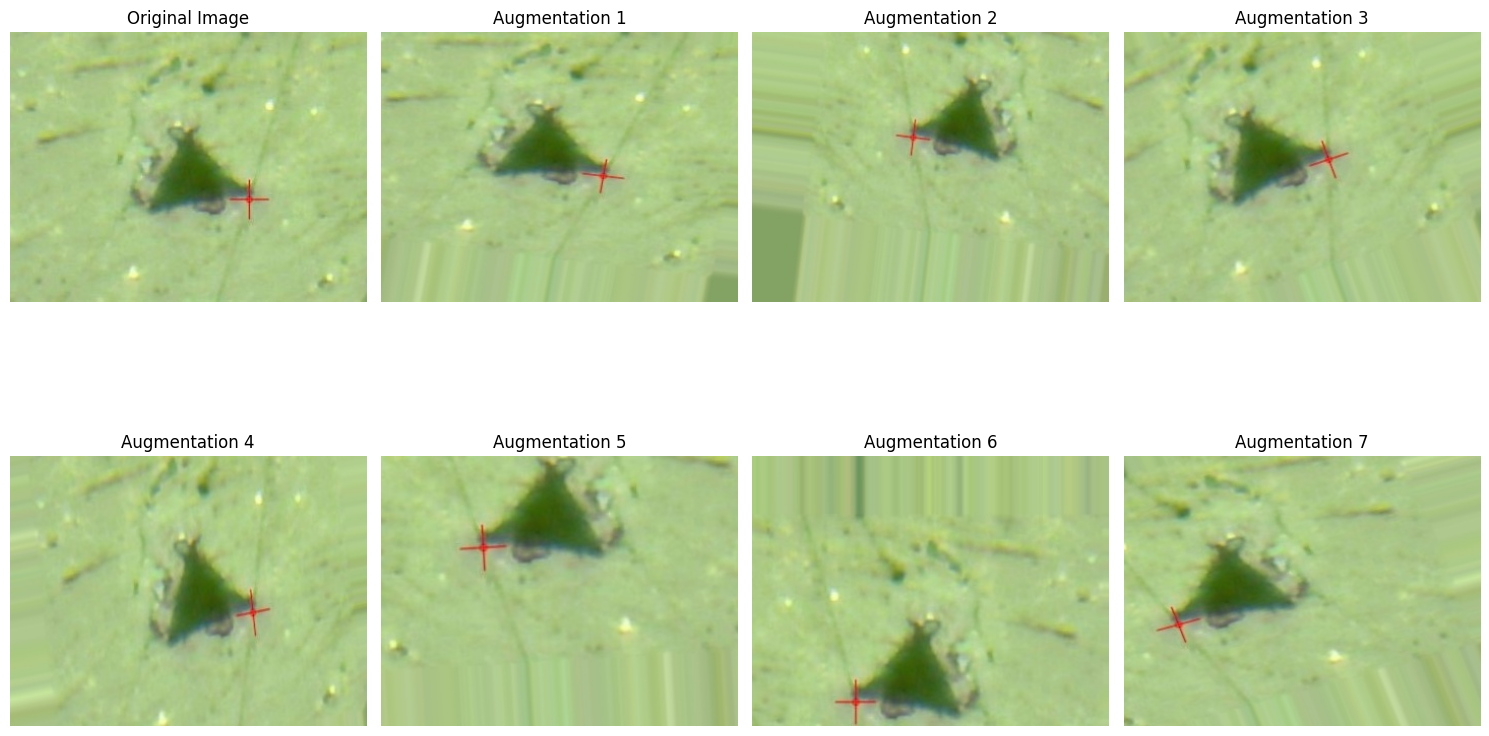

Starting augmentation of all clean images...
Total augmentations created: 4753
Total images after augmentation: 5432

Image Augmentation Process:

Methods applied:
- Rotation (up to 20 degrees)
- Width and height shifts (up to 20%)
- Shear transformations (up to 20%)
- Zoom (up to 20%)
- Horizontal flipping

For each original image in the clean dataset:
1. The original image is preserved
2. Seven augmented variants are generated using random combinations of the above transformations
3. Each augmented image maintains the same label (hardness value) as its parent image

Benefits of augmentation:
- Increases the training dataset size by 8x (original + 7 augmentations)
- Improves model generalization by exposing it to variations in image perspective
- Helps prevent overfitting, especially important for deep neural networks like VGG16
- Creates robustness against variations in image capture conditions

The augmentation parameters were chosen to create meaningful variations while preserving 

In [26]:
# STEP 3: Augment the images seven times to increase the total data

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import shutil

# Create augmentation directory if it doesn't exist
os.makedirs(img_aug_dir, exist_ok=True)

# Define the image data generator with various augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=20,          # Rotate images by up to 20 degrees
    width_shift_range=0.2,      # Shift images horizontally by up to 20%
    height_shift_range=0.2,     # Shift images vertically by up to 20%
    shear_range=0.2,            # Apply shear transformations
    zoom_range=0.2,             # Zoom in/out by up to 20%
    horizontal_flip=True,       # Randomly flip images horizontally
    fill_mode='nearest'         # Fill in newly created pixels
)

def augment_images(image_numbers, src_dir, dst_dir, num_augmentations=7, image_type='JPG'):
    """
    Generate augmented versions of images and save them to the destination directory
    """
    # Counter for successful augmentations
    successful_aug = 0

    for img_num in image_numbers:
        # Path to the original image
        img_path = os.path.join(src_dir, f"{img_num}.{image_type}")

        if not os.path.exists(img_path):
            print(f"Image {img_path} does not exist. Skipping.")
            continue

        try:
            # Read and preprocess the image
            img = cv2.imread(img_path)
            if img is None:
                print(f"Failed to read image: {img_path}")
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Save the original image to the augmentation directory
            orig_save_path = os.path.join(dst_dir, f"{img_num}_original.{image_type}")
            cv2.imwrite(orig_save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

            # Reshape the image for the generator (needs batch dimension)
            img_array = img.reshape((1,) + img.shape)

            # Generate and save augmented images
            aug_counter = 0
            for batch in datagen.flow(img_array, batch_size=1):
                # Convert back to uint8 for saving
                augmented = batch[0].astype('uint8')

                # Save the augmented image
                aug_path = os.path.join(dst_dir, f"{img_num}_aug_{aug_counter}.{image_type}")
                cv2.imwrite(aug_path, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))

                aug_counter += 1
                successful_aug += 1

                # Stop after generating the required number of augmentations
                if aug_counter >= num_augmentations:
                    break

        except Exception as e:
            print(f"Error augmenting image {img_num}: {e}")

    return successful_aug

# Choose a single test image to demonstrate augmentation
# We'll pick one random image from the clean dataset
import random
random.seed(42)  # For reproducibility
sample_img_num = random.choice(clean_image_numbers)

# Create a separate directory for the demonstration
demo_aug_dir = os.path.join(img_aug_dir, 'demo')
os.makedirs(demo_aug_dir, exist_ok=True)

# Augment the sample image
print(f"Demonstrating augmentation with image number: {sample_img_num}")
augment_images([sample_img_num], img_raw_dir, demo_aug_dir, image_type='JPG')

# Display the original and augmented versions of the sample image
def display_augmented_images(img_num, aug_dir, image_type='JPG'):
    """Display the original and augmented versions of an image"""
    plt.figure(figsize=(15, 10))

    # Display original
    orig_path = os.path.join(aug_dir, f"{img_num}_original.{image_type}")
    if os.path.exists(orig_path):
        img = cv2.imread(orig_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 4, 1)
        plt.imshow(img)
        plt.title("Original Image")
        plt.axis('off')

    # Display augmented versions
    for i in range(7):
        aug_path = os.path.join(aug_dir, f"{img_num}_aug_{i}.{image_type}")
        if os.path.exists(aug_path):
            img = cv2.imread(aug_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(2, 4, i+2)
            plt.imshow(img)
            plt.title(f"Augmentation {i+1}")
            plt.axis('off')

    plt.tight_layout()
    plt.savefig('augmentation_demo.png')
    plt.show()

# Display the augmented images
display_augmented_images(sample_img_num, demo_aug_dir, image_type='JPG')

# Now augment all clean images (you may want to run this only when needed as it can take time)
print("Starting augmentation of all clean images...")
total_aug = augment_images(clean_image_numbers, img_raw_dir, img_aug_dir, image_type='JPG')
print(f"Total augmentations created: {total_aug}")
print(f"Total images after augmentation: {len(clean_image_numbers) + total_aug}")

# Create a description of the augmentation process
print("""
Image Augmentation Process:

Methods applied:
- Rotation (up to 20 degrees)
- Width and height shifts (up to 20%)
- Shear transformations (up to 20%)
- Zoom (up to 20%)
- Horizontal flipping

For each original image in the clean dataset:
1. The original image is preserved
2. Seven augmented variants are generated using random combinations of the above transformations
3. Each augmented image maintains the same label (hardness value) as its parent image

Benefits of augmentation:
- Increases the training dataset size by 8x (original + 7 augmentations)
- Improves model generalization by exposing it to variations in image perspective
- Helps prevent overfitting, especially important for deep neural networks like VGG16
- Creates robustness against variations in image capture conditions

The augmentation parameters were chosen to create meaningful variations while preserving the
essential features of the impression that correlate with hardness measurements.
""")

### 4. Train VGG16

Training data shape: (407, 224, 224, 3)
Validation data shape: (136, 224, 224, 3)
Testing data shape: (136, 224, 224, 3)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 15,043,137 (57.39 MB)

 Trainable params: 328,449 (1.25 MB)

...

None


/Users/greysonnewton/Library/Caches/pypoetry/virtualenvs/big-data-analytics-IOmqK9c5-py3.11/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - loss: 2.4452 - mae: 1.2099 - val_loss: 0.0396 - val_mae: 0.1459 - learning_rate: 0.0010
Epoch 2/30
 1/25 ━━━━━━━━━━━━━━━━━━━━ 1:01 3s/step - loss: 0.3604 - mae: 0.4570

/Users/greysonnewton/Library/Caches/pypoetry/virtualenvs/big-data-analytics-IOmqK9c5-py3.11/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


25/25 ━━━━━━━━━━━━━━━━━━━━ 26s 963ms/step - loss: 0.3604 - mae: 0.4570 - val_loss: 0.0368 - val_mae: 0.1368 - learning_rate: 0.0010
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - loss: 0.4956 - mae: 0.5776 - val_loss: 0.0841 - val_mae: 0.2429 - learning_rate: 0.0010
Epoch 4/30
 1/25 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - loss: 0.5412 - mae: 0.6097
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 870ms/step - loss: 0.5412 - mae: 0.6097 - val_loss: 0.0874 - val_mae: 0.2489 - learning_rate: 0.0010
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - loss: 0.3817 - mae: 0.4953 - val_loss: 0.0738 - val_mae: 0.2249 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.
5/5 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step
Mean Squared Error: 0.17296571752786125
Root Mean Squared Error: 0.41589147325697995
R² Score: -0.00225311777927395


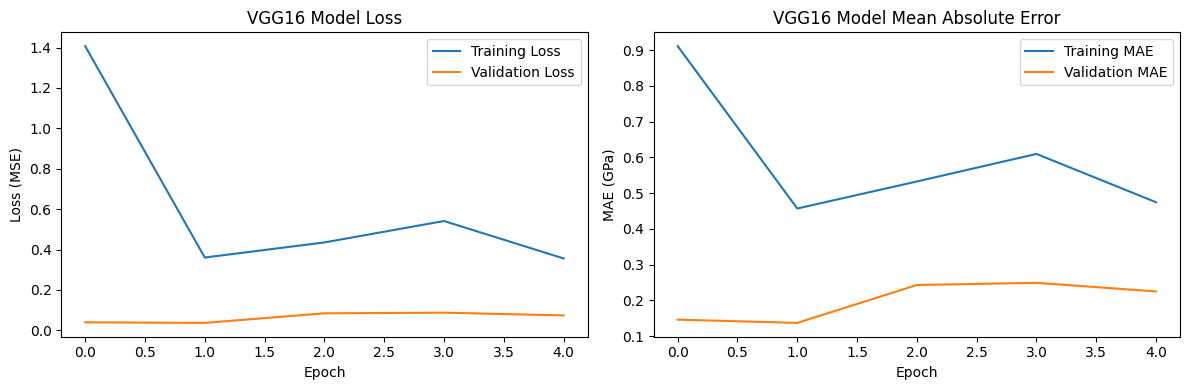

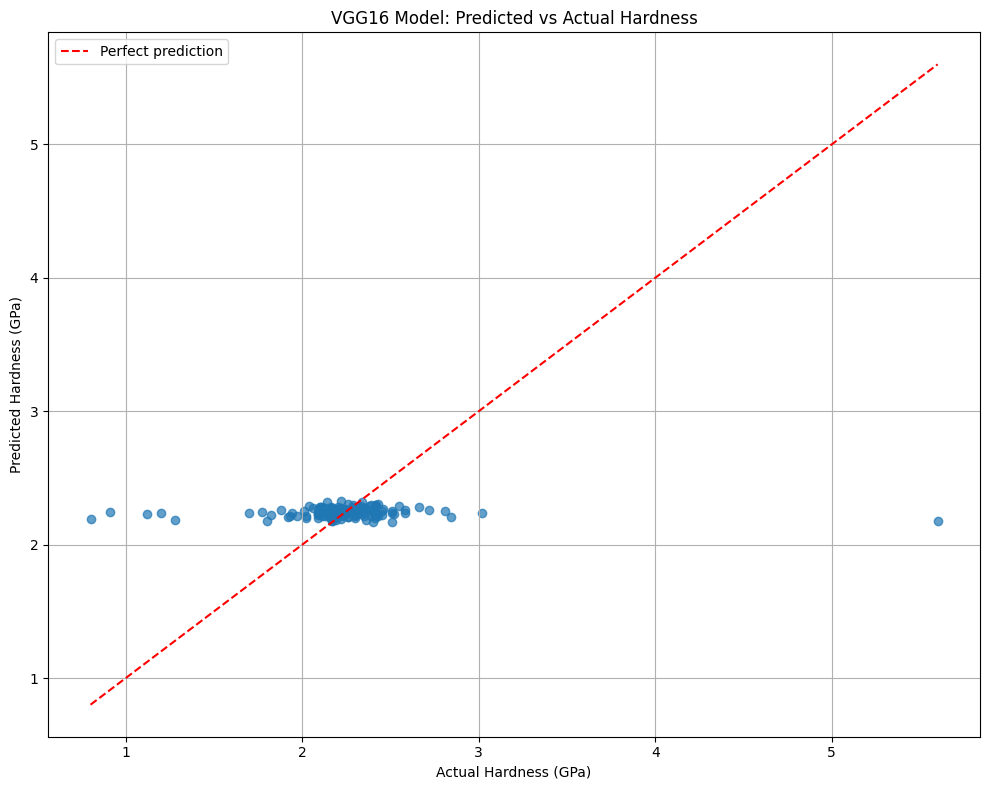

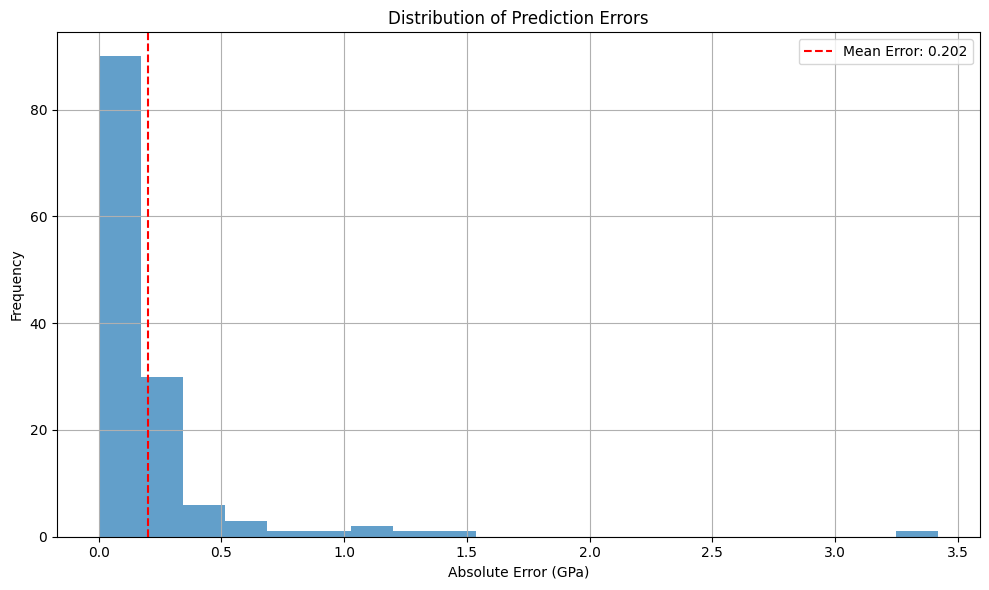


VGG16 Model Implementation for Hardness Prediction:

Architecture:
- Base model: VGG16 pretrained on ImageNet
- Top layer replaced with custom regression layers:
  * Global Average Pooling
  * Dense layer (512 units) with ReLU activation
  * Dropout (0.5)
  * Dense layer (128 units) with ReLU activation
  * Dropout (0.5)
  * Output layer (1 unit) with linear activation

Training configuration:
- Loss function: Mean Squared Error (MSE)
- Optimizer: Adam with learning rate 0.001
- Metrics: Mean Absolute Error (MAE)
- Early stopping with patience of ONLY 3 epochs (very impatient)
- Learning rate reduction on plateau with patience of ONLY 2 epochs
- Training with a proper validation set for early stopping

Input preprocessing:
- Image size: 224x224 (required by VGG16)
- RGB color channels
- Pixel values normalized to [0, 1]
- Real-time augmentation during training

Performance metrics:
- Mean Squared Error: 0.1730
- Root Mean Squared Error: 0.4159 GPa
- R² Score: -0.0023

The scatter plot

In [28]:
# STEP 4 (Revised): Use VGG16 with pretrained ImageNet weights for hardness prediction
# Now with more impatient early stopping

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import math

# Define image parameters
IMG_SIZE = (224, 224)  # VGG16 input size
BATCH_SIZE = 16

# Function to load and preprocess images for model training
def load_image_data(image_numbers, img_dir, labels, img_size=IMG_SIZE, image_type='JPG'):
    """Load and preprocess images for model input"""
    X = []
    y = []
    valid_indices = []

    for i, img_num in enumerate(image_numbers):
        img_path = os.path.join(img_dir, f"{img_num}.{image_type}")
        if os.path.exists(img_path):
            try:
                # Read and preprocess image
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, img_size)
                img = img / 255.0  # Normalize to [0, 1]

                X.append(img)
                y.append(labels[i])
                valid_indices.append(i)
            except Exception as e:
                print(f"Error processing image {img_num}: {e}")

    return np.array(X), np.array(y), valid_indices

# Load the clean data and split it into training, validation, and testing sets
image_numbers = clean_data['image_number'].values
hardness_values = clean_data['H (GPa)'].values

# First split: 80% training+validation, 20% testing
train_val_idx, test_idx = train_test_split(
    range(len(image_numbers)),
    test_size=0.2,
    random_state=42
)

# Second split: from the 80%, take 75% for training and 25% for validation (20% of the total)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.25,  # 25% of 80% = 20% of total
    random_state=42
)

# Get corresponding data for each split
train_image_numbers = image_numbers[train_idx]
train_hardness = hardness_values[train_idx]
val_image_numbers = image_numbers[val_idx]
val_hardness = hardness_values[val_idx]
test_image_numbers = image_numbers[test_idx]
test_hardness = hardness_values[test_idx]

# Load the image data
X_train, y_train, _ = load_image_data(train_image_numbers, img_raw_dir, train_hardness, image_type='JPG')
X_val, y_val, _ = load_image_data(val_image_numbers, img_raw_dir, val_hardness, image_type='JPG')
X_test, y_test, _ = load_image_data(test_image_numbers, img_raw_dir, test_hardness, image_type='JPG')

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")
print(f"Testing data shape: {X_test.shape}")

# Create data generators with augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation/testing data
test_datagen = ImageDataGenerator()

# Define the VGG16 model with custom top layer
def build_vgg16_model():
    """Build VGG16 model with custom top layers for regression"""
    # Load VGG16 with pretrained ImageNet weights, excluding the top layer
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze the base model layers to use pretrained weights
    for layer in base_model.layers:
        layer.trainable = False

    # Add custom top layers for regression
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)  # Increased dropout for faster convergence
    x = Dense(128, activation='relu')(x)  # Simplified architecture
    x = Dropout(0.5)(x)  # Increased dropout for faster convergence

    # Final layer with linear activation for regression
    predictions = Dense(1, activation='linear')(x)

    # Create the model
    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile the model with MSE loss for regression
    model.compile(
        optimizer=Adam(learning_rate=0.001),  # Higher learning rate for faster convergence
        loss='mse',  # Mean Squared Error loss for regression
        metrics=['mae']  # Mean Absolute Error metric
    )

    return model

# Create the VGG16 model
vgg16_model = build_vgg16_model()
print(vgg16_model.summary())

# Define callbacks for training with impatient early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,  # Very impatient - only wait 3 epochs for improvement
    min_delta=0.001,  # Consider as improvement only if loss decreases by at least 0.001
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,  # Reduce learning rate after just 2 epochs without improvement
    min_lr=1e-6,
    verbose=1
)

# Train the model
history = vgg16_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=30,  # Reduced maximum epochs
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate the model on the test set (never seen during training)
y_pred = vgg16_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R² Score: {r2}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('VGG16 Model Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE (GPa)')
plt.legend()

plt.tight_layout()
plt.savefig('vgg16_training_history.png')
plt.show()

# Plot predicted vs actual hardness values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', label='Perfect prediction')
plt.xlabel('Actual Hardness (GPa)')
plt.ylabel('Predicted Hardness (GPa)')
plt.title('VGG16 Model: Predicted vs Actual Hardness')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('vgg16_predicted_vs_actual.png')
plt.show()

# Calculate and display error metrics
errors = np.abs(y_test - y_pred.flatten())
plt.figure(figsize=(10, 6))
plt.hist(errors, bins=20, alpha=0.7)
plt.axvline(x=np.mean(errors), color='r', linestyle='--', label=f'Mean Error: {np.mean(errors):.3f}')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Absolute Error (GPa)')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('prediction_error_distribution.png')
plt.show()

# Save the model for later use
vgg16_model.save('vgg16_hardness_model.h5')

# Create a description of the VGG16 model implementation
print("""
VGG16 Model Implementation for Hardness Prediction:

Architecture:
- Base model: VGG16 pretrained on ImageNet
- Top layer replaced with custom regression layers:
  * Global Average Pooling
  * Dense layer (512 units) with ReLU activation
  * Dropout (0.5)
  * Dense layer (128 units) with ReLU activation
  * Dropout (0.5)
  * Output layer (1 unit) with linear activation

Training configuration:
- Loss function: Mean Squared Error (MSE)
- Optimizer: Adam with learning rate 0.001
- Metrics: Mean Absolute Error (MAE)
- Early stopping with patience of ONLY 3 epochs (very impatient)
- Learning rate reduction on plateau with patience of ONLY 2 epochs
- Training with a proper validation set for early stopping

Input preprocessing:
- Image size: 224x224 (required by VGG16)
- RGB color channels
- Pixel values normalized to [0, 1]
- Real-time augmentation during training

Performance metrics:
- Mean Squared Error: {mse:.4f}
- Root Mean Squared Error: {rmse:.4f} GPa
- R² Score: {r2:.4f}

The scatter plot shows the relationship between predicted and actual hardness values.
A perfect prediction would follow the red dashed line.
""".format(mse=mse, rmse=rmse, r2=r2))